# Importing Libraries and Data

<font color='blue'>Cell 1
Importing libraries

In [88]:
## Upload data from Module 3 data folder: 

# data1.csv 

# Note, make sure not to upload the data1.csv from Module 2

In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

<font color='blue'>Cell 2
Reading the data

In [90]:
#read data from csv
iris = pd.read_csv("data/IrisData1.csv")
selected_rows = [0, 1, 50, 51, 100, 101]
print(iris.iloc[selected_rows])


     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width          Species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
50            7.0          3.2           4.7          1.4  Iris-versicolor
51            6.4          3.2           4.5          1.5  Iris-versicolor
100           6.3          3.3           6.0          2.5   Iris-virginica
101           5.8          2.7           5.1          1.9   Iris-virginica


<font color='blue'>Cell 3
Dataset verification

In [91]:
#Check the dataset to make sure no data is missing and Check the class labels
def verify_dataset(data):
  #if any of the rows have missing value return datas missing
  data_found = 1
  for each_column in data.columns:
    if data[each_column].isnull().any():
            print("Data missing in Column " + each_column)
            #if any rows are not missing return Dataset is complete. No missing value
            quit()
    if data_found == 1:
        print("Dataset is complete. No missing values")
    return

verify_dataset(iris)

Dataset is complete. No missing values


<font color='blue'>Cell 4
One hot encoding function

In [92]:
#This function accepts an array of categorical variables and returns the one hot encoding
def to_one_hot(Y):
    n_col = np.amax(Y) + 1
    binarized = np.zeros((len(Y), n_col))
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized


<font color='blue'>Cell 5
Data normalization function

In [93]:
#Normalize array
def normalize(X, axis=-1, order=2):
    l2 = np.atleast_1d(np.linalg.norm(X, order, axis))
    l2[l2 == 0] = 1
    return X / np.expand_dims(l2, axis)

<font color='blue'>Cell 6
Activation function definitions

In [94]:
#sigmoid and its derivative
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    return sigmoid(x)*(1 - sigmoid(x))

def user_softmax(A):
    expA = np.exp(A)
    return expA / expA.sum(axis=1, keepdims=True)

<font color='blue'>Cell 7
Selecting features from a list

In [95]:
'''Change the values below'''
sepal_length = True
sepal_width = True
petal_length = True
petal_width = True
'''Change the values above'''

feature_list = [sepal_length,sepal_width,petal_length,petal_width]

<font color='blue'>Cell 8
Selecting features and running the normalization function

In [96]:
#Specifying the input data "x"
columns = ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']
x = pd.DataFrame(iris, columns=columns)
x = x.to_numpy()
x = x[:,feature_list]
print(iris.iloc[selected_rows])


     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width          Species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
50            7.0          3.2           4.7          1.4  Iris-versicolor
51            6.4          3.2           4.5          1.5  Iris-versicolor
100           6.3          3.3           6.0          2.5   Iris-virginica
101           5.8          2.7           5.1          1.9   Iris-virginica


In [97]:

x = normalize(x)
print(x[selected_rows])


[[0.80377277 0.55160877 0.22064351 0.0315205 ]
 [0.82813287 0.50702013 0.23660939 0.03380134]
 [0.76701103 0.35063361 0.51499312 0.15340221]
 [0.74549757 0.37274878 0.52417798 0.17472599]
 [0.65387747 0.34250725 0.62274045 0.25947519]
 [0.69052512 0.32145135 0.60718588 0.22620651]]


<font color='blue'>Cell 9
Labelling output data and applying one hot encoding

In [98]:
#Replace the species with 1,2 or 3 as appropriate
label_dict = dict()
label_dict['0'] = 'setosa'
label_dict['1'] = 'virginica'
label_dict['2'] = 'versicolor'
iris['Species'].replace(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor'], [0, 1, 2], inplace=True)

#Get Output, flatten and encode to one-hot
columns = ['Species']

y = pd.DataFrame(iris, columns=columns)
y = y.to_numpy()
y = y.flatten()
y = to_one_hot(y)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12644\2979211144.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  iris['Species'].replace(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor'], [0, 1, 2], inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12644\2979211144.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.

<font color='blue'>Cell 10
Train test splitting

In [99]:
x_y = pd.DataFrame(np.concatenate((x,y), axis=1))
def split_dataset_test_train(data,train_size):
  data = data.sample(frac=1).reset_index(drop=True)
  training_data = data.iloc[:int(train_size * len(data))].reset_index(drop=True)
  testing_data = data.iloc[int(train_size * len(data)):].reset_index(drop=True)
  return [training_data, testing_data]

np.random.seed(123456)

train_test_data = split_dataset_test_train(x_y,0.7)
X_train = train_test_data[0].iloc[:,0:4].to_numpy()
X_test = train_test_data[1].iloc[:,0:4].to_numpy()

y_train = train_test_data[0].iloc[:,-3:].to_numpy()
y_test = train_test_data[1].iloc[:,-3:].to_numpy()

print(X_train[selected_rows])
print(y_train[selected_rows])

[[0.77381111 0.59732787 0.2036345  0.05430253]
 [0.69594002 0.30447376 0.60894751 0.22835532]
 [0.71366557 0.28351098 0.61590317 0.17597233]
 [0.71576546 0.30196356 0.59274328 0.21249287]
 [0.76467269 0.31486523 0.53976896 0.15743261]
 [0.70779525 0.31850786 0.60162596 0.1887454 ]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


<font color='blue'>Cell 11
Training function definition

In [100]:
def initialize_network(input_size, hidden_size, output_size):
     
    w0 = 2*np.random.random((input_size, hidden_size)) - 1 
    w1 = 2*np.random.random((hidden_size, output_size)) - 1 
    bh = np.random.randn(hidden_size)
    bo = np.random.randn(output_size)
    return [w0, bh, w1, bo]



In [101]:
#sigmoid and its derivative
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    return sigmoid(x)*(1 - sigmoid(x))

def user_softmax(A):
    expA = np.exp(A)
    return expA / expA.sum(axis=1, keepdims=True)


def training(lr, batch_size, epochs, params):
  w0, bh, w1, bo = params 
   
  rem = len(X_train) % batch_size
  num_batch = len(X_train)//batch_size
  if rem != 0:
    num_batch += 1

  #Errors - for graph later
  errors = []

  for epoch in range(epochs):
    for curr_batch in range(num_batch):
        # Finding the current batch
        batch_start = curr_batch * batch_size
        batch_end = batch_start + batch_size
        input_batch = X_train[batch_start:batch_end]
        
        # First layer propagation
        zh = np.dot(input_batch, w0) + bh
        layer1 = sigmoid(zh)

        # Second layer propagation
        zo = np.dot(layer1, w1) + bo
        layer2 = user_softmax(zo)

    ########## Back Propagation

    ########## Phase 1
        labels_batch = y_train[batch_start:batch_end]
        layer2_error = layer2 - labels_batch
        layer2w_delta = np.dot(layer1.T, layer2_error)

        layer2b_delta = layer2_error

    ########## Phases 2

        dcost_dah = np.dot(layer2_error , w1.T)
        dah_dzh = sigmoid_deriv(zh)
        
        layer1_error = dah_dzh * dcost_dah
        layer1w_delta = np.dot(input_batch.T, layer1_error)

        layer1b_delta = layer1_error

        # Update Weights ================

        w0 -= lr * layer1w_delta
        bh -= lr * layer1b_delta.sum(axis=0)

        w1 -= lr * layer2w_delta
        bo -= lr * layer2b_delta.sum(axis=0)

    error = np.mean(np.abs(layer2_error))
    errors.append(error)

  return [w0,bh,w1,bo], error, errors

<font color='blue'>Cell 12
Evaluation function definition

In [102]:
def evaluation(params,tst_set):
  w0 = params[0]
  bh = params[1]
  w1 = params[2]
  bo = params[3]

  # First layer propagation
  zh = np.dot(tst_set, w0) + bh
  layer1 = sigmoid(zh)

  # Second layer propagation
  zo = np.dot(layer1, w1) + bo
  layer2 = user_softmax(zo)

  return layer2

# Exercise 1

<font color='blue'>Cell 13
Selecting parameters and running the training function

In [103]:
input_size= X_train.shape[1]
hidden_size = 5
output_size=3

np.random.seed(654321)
params = initialize_network(input_size, hidden_size, output_size)
params_rounded = [np.round(param, 3) for param in params]
params_rounded

[array([[-0.536,  0.465,  0.926,  0.386,  0.719],
        [ 0.677, -0.843, -0.857, -0.935,  0.937],
        [ 0.371, -0.867, -0.663, -0.399, -0.094],
        [-0.279, -0.578,  0.076, -0.16 ,  0.017]]),
 array([-0.808, -0.437,  2.342, -1.639, -2.43 ]),
 array([[ 0.558,  0.447,  0.572],
        [ 0.749,  0.66 , -0.395],
        [ 0.6  , -0.924, -0.553],
        [ 0.255,  0.354,  0.934],
        [-0.671,  0.216,  0.079]]),
 array([ 1.105, -0.175,  1.103])]

In [104]:
'''You may Change these values'''
learning_rate = 0.01
batch_size = 10
epochs = 1000

In [105]:


trained_params, error, errors = training(learning_rate, batch_size, epochs, params)

<font color='blue'>Cell 14
Displaying the errors from training

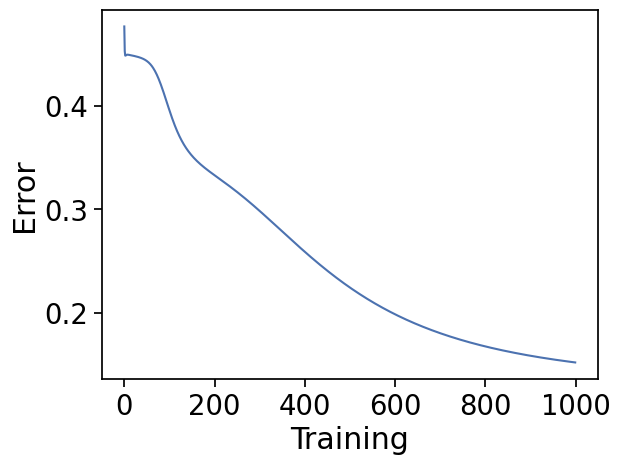

Training Accuracy 84.82%


In [106]:
#Plot the accuracy chart
accuracy = (1 - error) * 100

plt.plot(errors)
plt.xlabel('Training')
plt.ylabel('Error')
plt.show()
        
print("Training Accuracy " + str(round(accuracy,2)) + "%")

<font color='blue'>Cell 15
Running the evaluation function

In [107]:
y_pred = evaluation(trained_params,X_test)

<font color='blue'>Cell 16
Displaying the confusion matrix

In [108]:
y_actual = pd.Series(y_test.argmax(axis=1))
y_pred = pd.Series(y_pred.argmax(axis=1))
cm = pd.crosstab(y_actual,y_pred).to_numpy()
cm

array([[14,  0,  0],
       [ 0, 12,  4],
       [ 0,  0, 15]], dtype=int64)

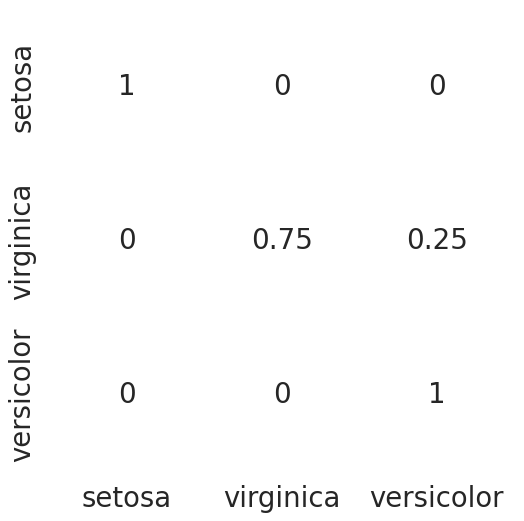

In [109]:

if cm.shape[1]<3:
  cm = np.concatenate((cm,np.zeros((3,3-cm.shape[1]))),axis=1)

cm_norm = np.array([cm[i][j]/cm[i].sum() for i in range(cm.shape[0]) for j in range(cm.shape[1])])
cm_norm = cm_norm.reshape(3,3)


import seaborn as sns
from matplotlib.colors import ListedColormap


df_cm = pd.DataFrame(cm_norm, index = ['setosa','virginica','versicolor'],
                  columns = ['setosa','virginica','versicolor'])


plt.figure(figsize = (6,6))

with sns.axes_style('white'):
    sns.heatmap(df_cm,
                cbar=False,
                square=False,
                annot=True,
                annot_kws={"size": 20},
                cmap=ListedColormap(['white']),
                linewidths=0.5)
    sns.set(font_scale=1.8)

# Exercise 2

<font color='blue'>Cell 17
Function for testing flower dimensions

In [ ]:

def input_test_seq():
    sepal_length = float(input('Enter the Sepal length in cm :'))
    while True:
        if float(sepal_length)< 0 or float(sepal_length) > 10:
            print('Inalid Entry. Enter Sepal Length <10 \n')
            sepal_length = float(input('Enter the sepal length in cm :'))
            continue
        else:
            break

    sepal_width = float(input('Enter the Sepal width in cm :'))
    while True:
        if float(sepal_width) < 0 or float(sepal_width) > 10:
            print('Invalid entry')
            sepal_width = float(input('Enter the sepal width in cm :'))
            continue
        else:
            break

    petal_length = float(input('Enter the petal length in cm :'))
    while True:
        if float(petal_length) <0 or float(petal_length) > 10:
            print('Inalid Entry. Please enter value less than 10')
            petal_length = float(input('Enter the petal length in cm :'))
            continue
        else:
            break

    petal_width = float(input('Enter the petal width in cm :'))
    while True:
        if float(petal_width) < 0 or float(petal_width) > 10:
            print('Invalid entry')
            petal_width = float(input('Enter the petal width in cm :'))
            continue
        else:
            break

    predict_features = [sepal_length,sepal_width,petal_length,petal_width]
    predict_features = normalize(predict_features)
    result_category = evaluation(trained_params,predict_features)
    result_category = result_category.argmax(axis=1)[0]

    if result_category == 0:
        value_prediction = "Iris-setosa"
    elif result_category == 1:
        value_prediction = "Iris-versicolor"
    elif result_category == 2:
        value_prediction = "Iris-virginica"
    return value_prediction

flower_prediction = input_test_seq()
print("The flower is most likely", flower_prediction)

Enter the Sepal length in cm :5.1
Enter the Sepal width in cm :3.4
Enter the petal length in cm :1.4
Enter the petal width in cm :0.2
The flower is most likely Iris-setosa
